References: 
1. https://www.reneshbedre.com/blog/kmeans-clustering-python.html
https://jakevdp.github.io/PythonDataScienceHandbook/05.11-k-means.html
2. https://www.reneshbedre.com/blog/dbscan-python.html


In [3]:
import numpy as np #linear algebra 
import pandas as pd #creating and manipulating dataframes
import matplotlib.pyplot as plt #visuals
import seaborn as sns #visuals
from sklearn.neighbors import NearestNeighbors

from yellowbrick.cluster import KElbowVisualizer

from sklearn.cluster import KMeans #K-Means
from sklearn.cluster import DBSCAN #DBSCAN

from sklearn.preprocessing import StandardScaler #scaler

# K-Means

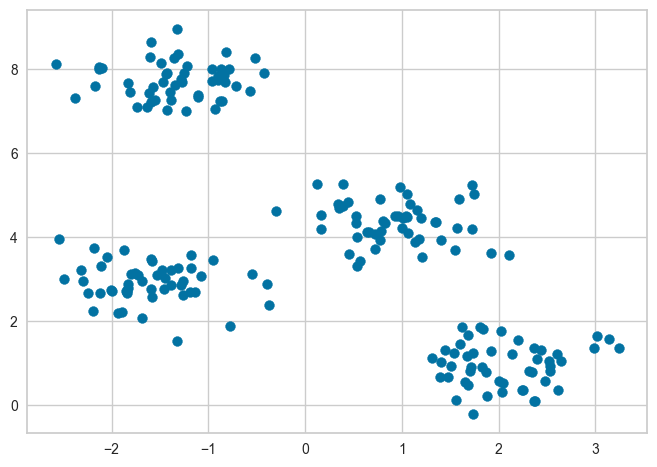

In [4]:
from sklearn.datasets import make_blobs
import pandas as pd

dataset, classes = make_blobs(n_samples=200, n_features=2, centers=4, cluster_std=0.5, random_state=0)

# make as panda dataframe for easy understanding
df = pd.DataFrame(dataset, columns=['var1', 'var2'])
df.head(2)
plt.scatter(dataset[:, 0], dataset[:, 1], s=50);

In [5]:
df

,var1,var2
0,2.204387,1.560857
1,-1.133740,2.684673
2,1.064983,4.102897
3,-2.376038,7.324207
4,1.682890,0.484444
...,...,...
195,-1.853108,2.722406
196,-1.313775,3.256336
197,0.999149,4.210195
198,-1.110998,7.390002


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to '

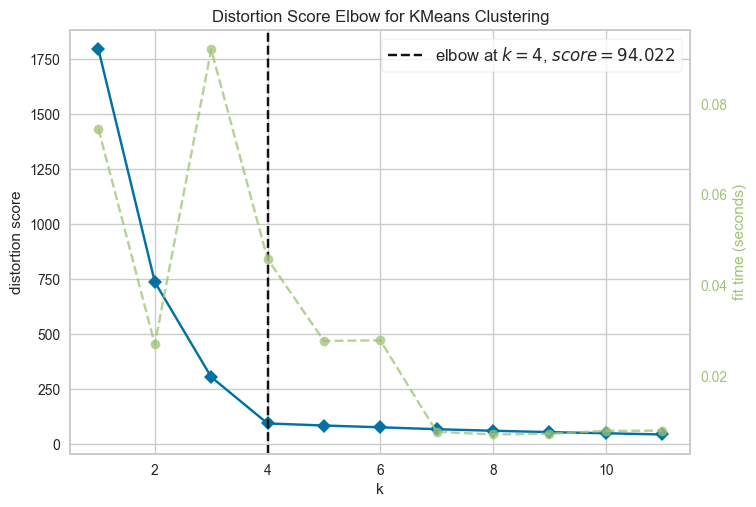

<AxesSubplot: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [6]:
model = KMeans()
visualizer = KElbowVisualizer(model, k=(1,12)).fit(df)
visualizer.show()

In [8]:
kmeans = KMeans(n_clusters=4, init='k-means++', random_state=0, n_init=10).fit(df)

In [9]:
kmeans.labels_  

array([1, 0, 3, 2, 1, 3, 0, 3, 3, 3, 3, 1, 0, 0, 1, 3, 2, 2, 2, 1, 2, 0,
       1, 0, 1, 1, 2, 1, 1, 3, 2, 3, 0, 1, 0, 3, 0, 3, 3, 2, 2, 2, 2, 3,
       1, 0, 3, 2, 2, 3, 2, 0, 0, 2, 3, 2, 0, 1, 3, 1, 2, 3, 1, 3, 2, 3,
       1, 2, 0, 0, 1, 1, 3, 3, 0, 2, 0, 0, 1, 1, 2, 3, 1, 0, 0, 3, 3, 1,
       0, 0, 2, 2, 2, 3, 3, 1, 0, 2, 3, 3, 2, 1, 1, 2, 2, 0, 3, 1, 1, 3,
       2, 0, 0, 1, 1, 3, 0, 0, 2, 3, 2, 0, 3, 1, 3, 0, 3, 0, 1, 3, 0, 1,
       0, 2, 2, 0, 2, 2, 1, 2, 1, 0, 1, 1, 0, 1, 3, 1, 0, 2, 2, 2, 3, 0,
       1, 3, 2, 0, 2, 1, 2, 1, 1, 0, 0, 2, 3, 1, 1, 0, 1, 3, 0, 2, 2, 2,
       3, 3, 0, 3, 0, 1, 3, 1, 3, 0, 0, 2, 3, 2, 1, 1, 3, 2, 0, 0, 0, 3,
       2, 1], dtype=int32)

In [10]:
kmeans.inertia_

94.02242630751755

In [11]:
kmeans.n_iter_

2

In [12]:
kmeans.cluster_centers_

array([[-1.60782913,  2.9162828 ],
       [ 2.06911036,  0.96146833],
       [-1.33173192,  7.7400479 ],
       [ 0.91932803,  4.34824615]])

In [13]:
from collections import Counter
Counter(kmeans.labels_)

Counter({1: 50, 0: 50, 3: 50, 2: 50})

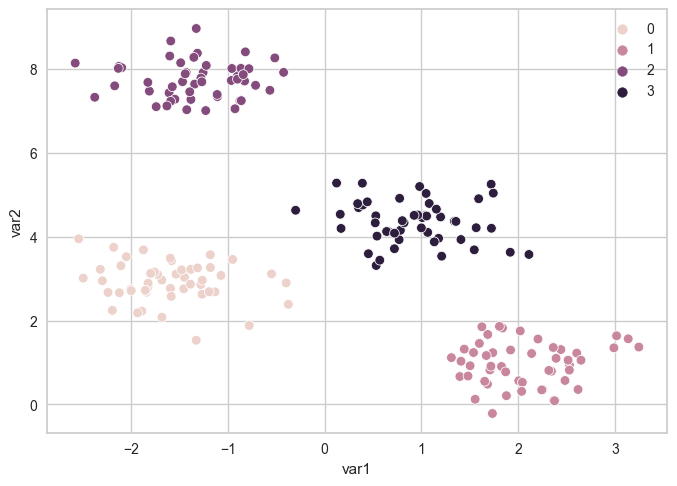

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.scatterplot(data=df, x="var1", y="var2", hue=kmeans.labels_)
plt.show()

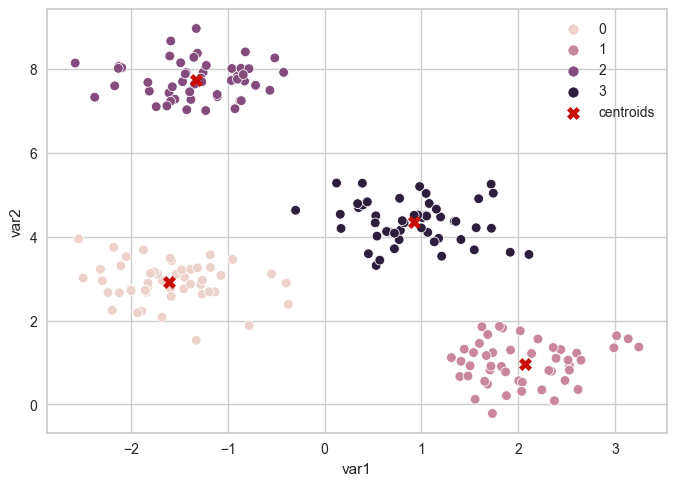

In [15]:
sns.scatterplot(data=df, x="var1", y="var2", hue=kmeans.labels_)
plt.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1], 
            marker="X", c="r", s=80, label="centroids")
plt.legend()
plt.show()

# DBScan

In [ ]:
# Get dataset

In [16]:
df = pd.read_csv("https://reneshbedre.github.io/assets/posts/tsne/tsne_scores.csv")
df.head(2)

URLError: <urlopen error [Errno 8] nodename nor servname provided, or not known>

In [ ]:
# check the shape of dataset
print(df.shape)

In [27]:
# Compute required parameters for DBSCAN clustering
# n_neighbors = 5 as kneighbors function returns distance of point to itself (i.e. first column will be zeros) 
nbrs = NearestNeighbors(n_neighbors = 5).fit(df)

# Find the k-neighbors of a point
neigh_dist, neigh_ind = nbrs.kneighbors(df)

# sort the neighbor distances (lengths to points) in ascending order
# axis = 0 represents sort along first axis i.e. sort along row
sort_neigh_dist = np.sort(neigh_dist, axis = 0)

In [30]:
sort_neigh_dist

array([[0.00000000e+00, 5.40629929e-03, 6.28547948e-02, 9.12104840e-02,
        1.88843911e-01],
       [0.00000000e+00, 5.40629929e-03, 6.54311707e-02, 1.13117739e-01,
        2.06027391e-01],
       [0.00000000e+00, 5.78476006e-03, 6.64854545e-02, 1.34345708e-01,
        2.89494168e-01],
       ...,
       [0.00000000e+00, 3.10020607e+00, 5.69197569e+00, 5.81652673e+00,
        5.85066405e+00],
       [0.00000000e+00, 3.79030401e+00, 1.03350868e+01, 1.03762254e+01,
        1.04848459e+01],
       [0.00000000e+00, 5.57200901e+00, 1.04168553e+01, 1.04557082e+01,
        1.05479535e+01]])

In [33]:
sort_neigh_dist[:, 4]

array([ 0.18884391,  0.20602739,  0.28949417, ...,  5.85066405,
       10.48484593, 10.5479535 ])

In [42]:
k_dist

array([ 0.18884391,  0.20602739,  0.28949417, ...,  5.85066405,
       10.48484593, 10.5479535 ])

In [68]:
len(k_dist)

4406

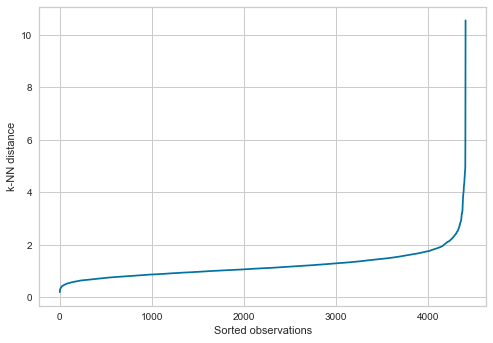

In [29]:
k_dist = sort_neigh_dist[:, 4]
plt.plot(k_dist)
plt.ylabel("k-NN distance")
plt.xlabel("Sorted observations")
plt.show()

In [44]:
from kneed import KneeLocator
kneedle = KneeLocator(x = range(1, len(neigh_dist)+1), y = k_dist, S = 1.0, 
                      curve = "concave", direction = "increasing", online=True)

# get the estimate of knee point
print(kneedle.knee_y)

4.5445133515748894


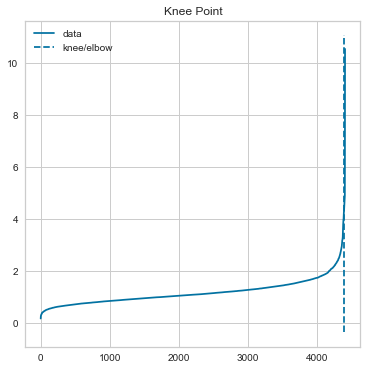

In [45]:
kneedle.plot_knee()
plt.show()

In [46]:
clusters = DBSCAN(eps = 4.54, min_samples = 4).fit(df)
# get cluster labels
clusters.labels_

array([0, 0, 1, ..., 1, 1, 1], dtype=int64)

In [47]:
# check unique clusters
set(clusters.labels_)

{-1, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10}

In [50]:
Counter(clusters.labels_)

Counter({0: 870,
         1: 1524,
         2: 769,
         3: 301,
         4: 153,
         5: 246,
         6: 232,
         7: 283,
         8: 11,
         9: 6,
         10: 8,
         -1: 3})

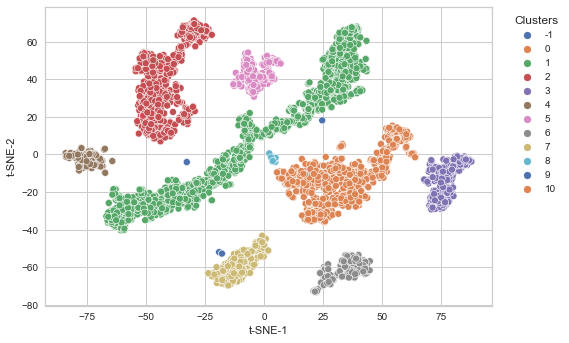

In [51]:
p = sns.scatterplot(data = df, x = "t-SNE-1", y = "t-SNE-2", hue = clusters.labels_, legend = "full", palette = "deep")
sns.move_legend(p, "upper right", bbox_to_anchor = (1.17, 1.), title = 'Clusters')
plt.show()

# K-Means comparaison 

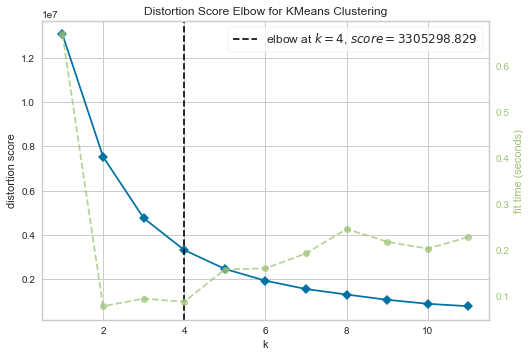

<AxesSubplot:title={'center':'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [52]:
model = KMeans()
visualizer = KElbowVisualizer(model, k=(1,12)).fit(df)
visualizer.show()

In [59]:
kmeans.labels_

array([1, 0, 3, 2, 1, 3, 0, 3, 3, 3, 3, 1, 0, 0, 1, 3, 2, 2, 2, 1, 2, 0,
       1, 0, 1, 1, 2, 1, 1, 3, 2, 3, 0, 1, 0, 3, 0, 3, 3, 2, 2, 2, 2, 3,
       1, 0, 3, 2, 2, 3, 2, 0, 0, 2, 3, 2, 0, 1, 3, 1, 2, 3, 1, 3, 2, 3,
       1, 2, 0, 0, 1, 1, 3, 3, 0, 2, 0, 0, 1, 1, 2, 3, 1, 0, 0, 3, 3, 1,
       0, 0, 2, 2, 2, 3, 3, 1, 0, 2, 3, 3, 2, 1, 1, 2, 2, 0, 3, 1, 1, 3,
       2, 0, 0, 1, 1, 3, 0, 0, 2, 3, 2, 0, 3, 1, 3, 0, 3, 0, 1, 3, 0, 1,
       0, 2, 2, 0, 2, 2, 1, 2, 1, 0, 1, 1, 0, 1, 3, 1, 0, 2, 2, 2, 3, 0,
       1, 3, 2, 0, 2, 1, 2, 1, 1, 0, 0, 2, 3, 1, 1, 0, 1, 3, 0, 2, 2, 2,
       3, 3, 0, 3, 0, 1, 3, 1, 3, 0, 0, 2, 3, 2, 1, 1, 3, 2, 0, 0, 0, 3,
       2, 1])

In [66]:
kmeans = KMeans(n_clusters=4, init='k-means++', random_state=0).fit(df)

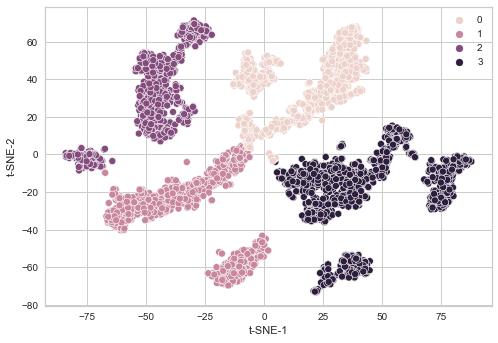

In [67]:
sns.scatterplot(data=df, x="t-SNE-1", y="t-SNE-2", hue=kmeans.labels_)
plt.show()

# End